# Clade C2 results

## Imports etc

In [1]:
import os
from datetime import datetime
save_res = True
is_SIS = False

In [2]:
# Create a folder for results:
if save_res:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_directory = f"res/elfi_res/C2_results/clade_C2_{timestamp}/"
    os.makedirs(output_directory)
    print(f"Created a result directory: {output_directory}")

Created a result directory: res/elfi_res/C2_results/clade_C2_2024-03-28_12-16-30/


In [3]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_C2.py grid_params.py

# Write grid params to file:
with open("grid_params.py", 'r') as f:
    grid_pars = f.read()
    
with open(os.path.join(output_directory, "grid_params.py"), 'w') as f:
    f.write(grid_pars)


In [4]:
# Import elfi_model.py
if not is_SIS:
    import elfi_model
    importlib.reload(elfi_model)
    from elfi_model import *
else:
    import elfi_model_SIS
    importlib.reload(elfi_model_SIS)
    from elfi_model_SIS import * 
    


Loading BSI_functions.py
Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
                           Best estimate      Collection Clade  \
0                                    NaN            NORM     A   
1                                    NaN            BSAC     A   
2  temporally and geographically matched           BSAC2     A   
3                                    NaN  BSAC_2003-2017     A   
4                                    NaN        Combined     A   

                Label  carriage_nonPP  Disease_nonPP  carriage_PP  Disease_PP  \
0            A (NORM)             387           3179           16          75   
1            A (BSAC)             387           1490           16          19   
2           A (BSAC2)             387            698           16          20   
3  A (BSAC_2003-2017)             387           1860           16          28   
4        A (Combined)             387           5367           16         114   

       OR   lower   upp

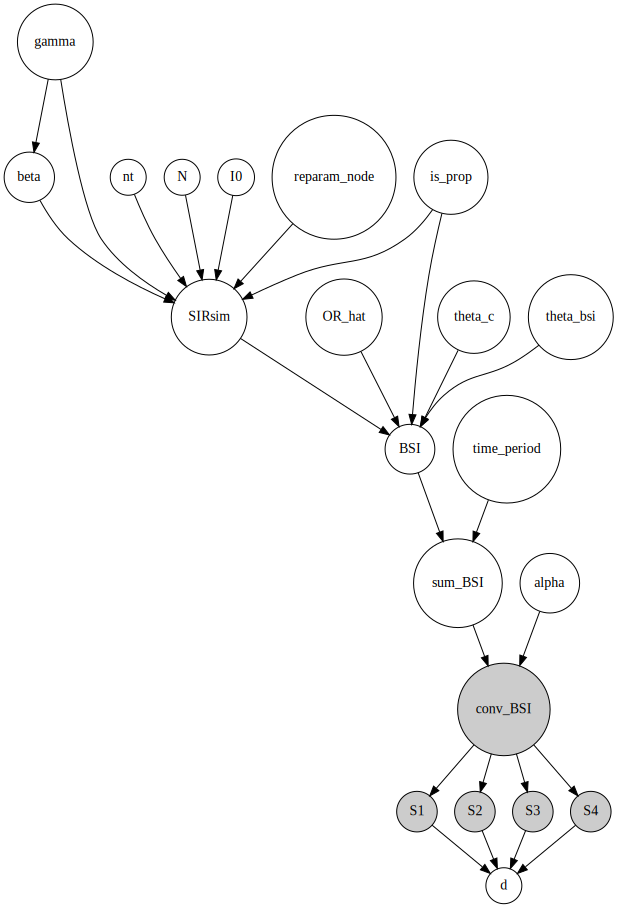

In [5]:
elfi.draw(m)

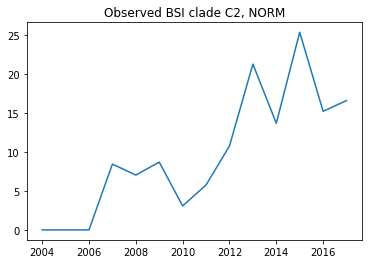

In [6]:
# Plot the observed data
plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.savefig(os.path.join(output_directory, "observed_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [7]:
get_OR_hat_pars(or_data, clade = "C2", dataset = "NORM")

(4.3577, 1.675325)

In [8]:
OR_hat.generate(10)

4.3577

## Visualizing the prior

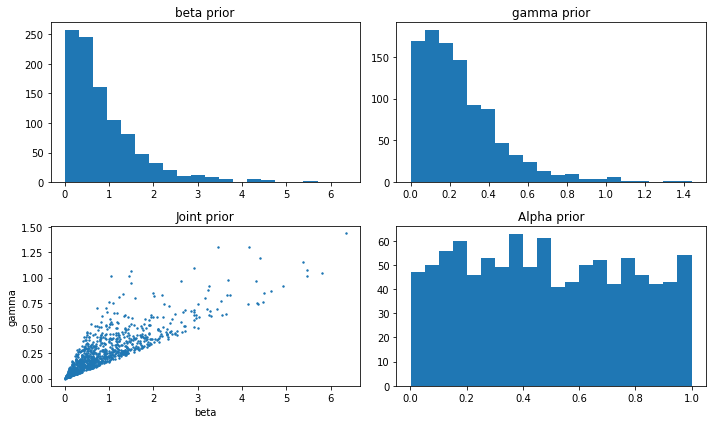

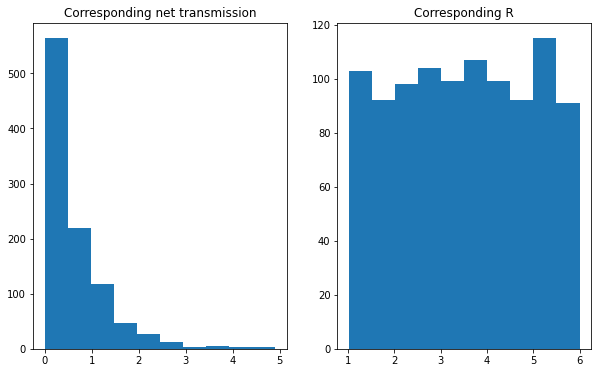

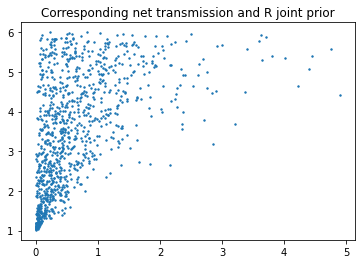

In [9]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    
    if par2 == "tau":
        g = 1/prior_sample[par2]
        plt.hist(prior_sample[par2])
        plt.title("Tau = mean infectious time")
        plt.show()
        p2_title = "gamma"
        
    else:
        g = prior_sample[par2]
        p2_title = par2
    #g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{p2_title} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{p2_title}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, "priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.savefig(os.path.join(output_directory, "corresponding_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.savefig(os.path.join(output_directory, "joint_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()

if not reparam:    
    plot_priors_elfi() #par2 = "tau"
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(os.path.join(output_directory, "R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.savefig(os.path.join(output_directory, "OR_prior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    

    

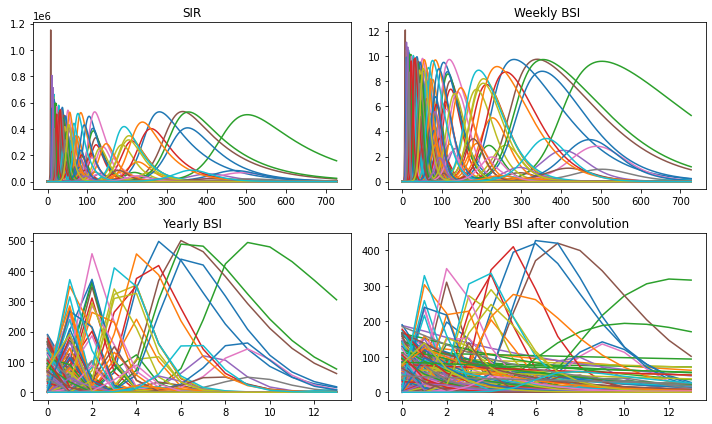

In [10]:
# Simulations from the prior:
if not is_SIS:
    sim_dict = m.generate(batch_size= 200, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])
else:
    sim_dict = m.generate(batch_size= 200, outputs = ["SISsim", "BSI", "conv_BSI", "sum_BSI"])
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

if not is_SIS:
    axs[0, 0].plot(sim_dict["SIRsim"][1][0:200].T)
    axs[0, 0].set_title(f'SIR')
else:
    axs[0, 0].plot(sim_dict["SISsim"][1][0:200].T)
    axs[0, 0].set_title(f'SIS')
axs[0, 1].plot(sim_dict["BSI"][0:200].T)
axs[0, 1].set_title(f'Weekly BSI')
axs[1, 0].plot(sim_dict["sum_BSI"][0:200].T)
axs[1, 0].set_title(f'Yearly BSI')
axs[1, 1].plot(sim_dict["conv_BSI"][0:200].T)
axs[1, 1].set_title(f'Yearly BSI after convolution')

plt.tight_layout()
plt.savefig(os.path.join(output_directory, "node_draws.pdf"), format="pdf", bbox_inches="tight")
plt.show()

Generating summary figures...
Done!


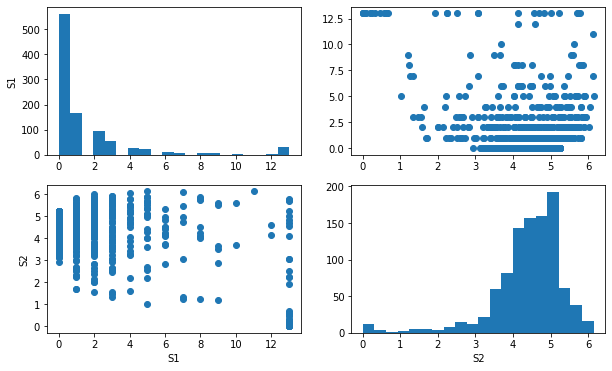

In [11]:
# Visualize summaries:

def get_4x4_summaries(val1, val2, fname = "4x4_plot.pdf"):
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))


    axs[0, 0].hist(ssample[f'{val1}'], bins = 20)
    axs[0, 0].set_ylabel(f'{val1}')
    axs[0, 1].scatter(ssample[f'{val2}'], ssample[f'{val1}'])
    axs[1, 0].scatter(ssample[f'{val1}'], ssample[f'{val2}'])
    axs[1, 0].set_ylabel(f'{val2}')
    axs[1, 0].set_xlabel(f'{val1}')
    #axs[1, 0].set_title(f'S2 and S1')
    axs[1, 1].hist(ssample[f'{val2}'], bins = 20)
    axs[1, 1].set_xlabel(f'{val2}')
    
    plt.savefig(os.path.join(output_directory, fname), format="pdf", bbox_inches="tight")
    #plt.show()
    

try:
    print("Generating summary figures...")
    ssample = m.generate(batch_size = 1000, outputs = ["S1", "S2"])
    get_4x4_summaries("S1", "S2", fname = "4x4_S1_S2_plot.pdf")
    #get_4x4_summaries("S2", "S3", fname = "4x4_S2_S3_plot.pdf")
    #get_4x4_summaries("S3", "S4", fname = "4x4_S3_S4_plot.pdf")
    #get_4x4_summaries("S4", "S5", fname = "4x4_S4_S5_plot.pdf")
    #get_4x4_summaries("S1", "S3", fname = "4x4_S1_S3_plot.pdf")
    #get_4x4_summaries("S1", "S4", fname = "4x4_S1_S4_plot.pdf")
    #get_4x4_summaries("S1", "S5", fname = "4x4_S1_S5_plot.pdf")
    #get_4x4_summaries("S2", "S4", fname = "4x4_S2_S4_plot.pdf")
    #get_4x4_summaries("S2", "S5", fname = "4x4_S2_S5_plot.pdf")
    #get_4x4_summaries("S3", "S5", fname = "4x4_S3_S5_plot.pdf")

    print("Done!")
except:
    print("Some summaries not included.")

## Rejection sampling

In [12]:
pars = variables = ["beta", "gamma", "alpha"]

In [13]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(10000, quantile = 0.005)

Progress [==================================================] 100.0% Complete
CPU times: user 9min 50s, sys: 9.18 s, total: 10min
Wall time: 9min 50s


In [14]:

import csv

with open(os.path.join(output_directory, "result_samples.csv"), "w") as csvfile:
    
    datawriter = csv.writer(csvfile)
    datawriter.writerow(variables)
    
    for i in range(0, len(result.samples[variables[0]])):
        
        row = []
        for v in variables:
            row.append(result.samples[v][i])
        #row = [result.samples["beta"][i], result.samples["gamma"][i], result.samples["alpha"][i], result.samples["l"][i]]
        #print(row)
        
        datawriter.writerow(row)
    

In [15]:
if reparam:
    pars_to_sample = ['net_transmission', 'R', 'alpha', 'l']
    #pars_to_sample = ['net_transmission', 'R', 'l']
else:
    #pars_to_sample = ['beta', 'gamma', 'alpha', 'l']
    pars_to_sample = variables

prior_sample = m.generate(10000, pars_to_sample)


with open(os.path.join(output_directory, "result_prior.csv"), "w") as csvfile:
    variables = pars_to_sample
    datawriter = csv.writer(csvfile)
    datawriter.writerow(variables)
    
    for i in range(0, len(prior_sample[variables[0]])):
        
        row = []
        for v in variables:
            row.append(prior_sample[v][i])
        #row = [result.samples["beta"][i], result.samples["gamma"][i], result.samples["alpha"][i], result.samples["l"][i]]
        #print(row)
        
        datawriter.writerow(row)

In [16]:
#rej = elfi.SMC(d, batch_size=100)
#%time result = rej.sample(1000, thresholds = [1e12, 10000, 1000]) # Problem: lack of logpdf for custom beta prior :)

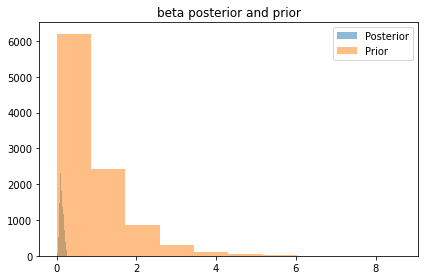

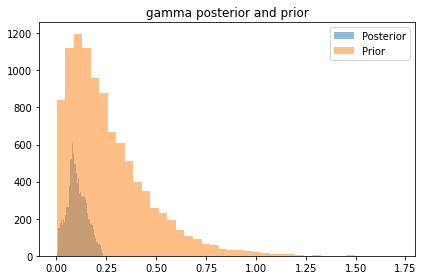

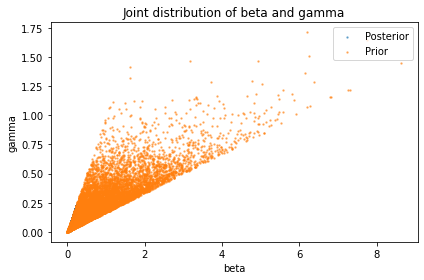

OR hat was not included as an estimated parameter.
Theta_bsi was not included as an estimated parameter.


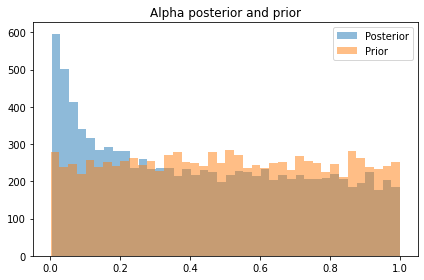

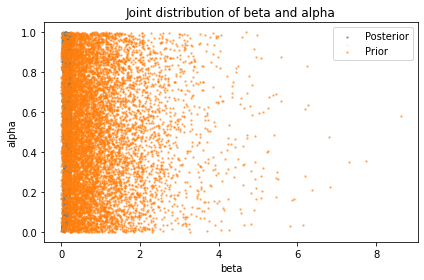

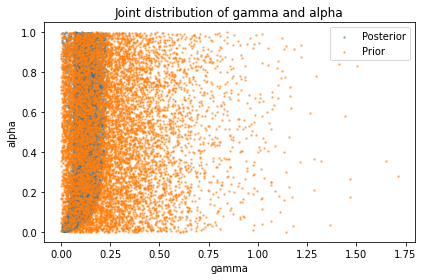

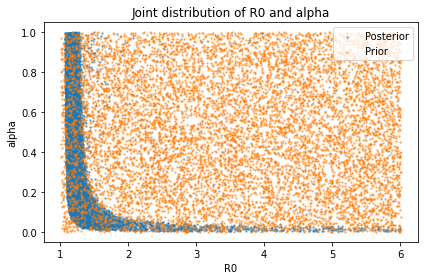

In [17]:
# Prior and posterior in the same figure
#pars_to_sample = ['OR_hat']
#pars_to_sample = ['theta_bsi']
#pars_to_sample = ['l']
#pars_to_sample = []

if reparam:
    par1 = "net_transmission"
    par2 = "R"
    
else:
    par1 = pars[0]
    par2 = pars[1]
    

pars_to_sample.append(par1)
pars_to_sample.append(par2)

pars_to_sample = pars

if not reparam:
    
    sample = m.generate(10000, pars_to_sample)
    
   

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"{par1}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par2} posterior and prior")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"{par2}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    
    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"joint_{par1}_{par2}_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    try:
        # OR_hat

        plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("OR_hat posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("OR hat was not included as an estimated parameter.")

    try:
        # theta_bsi
        plt.hist(result.samples['theta_bsi'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['theta_bsi'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Theta_bsi posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("Theta_bsi was not included as an estimated parameter.")
        
    try:
        # OR_hat

        plt.hist(result.samples['alpha'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['alpha'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Alpha posterior and prior")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        print("Alpha was not included as an estimated parameter.")
    
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and OR_hat")
        plt.xlabel(f"{par1}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and OR_hat")
        plt.xlabel(f"{par2}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_OR_hat_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        pass
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and alpha")
        plt.xlabel(f"{par1}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and alpha")
        plt.xlabel(f"{par2}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    except:
        
        pass
    
    try:
        # Joint prior: par1, theta_bsi

        plt.scatter(result.samples[par1], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and theta_bsi")
        plt.xlabel(f"{par1}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par1}_theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        # Joint prior: par2, theta_bsi

        plt.scatter(result.samples[par2], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and theta_bsi")
        plt.xlabel(f"{par2}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_{par2}_theta_bsi_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
        plt.show()
    
    except:
        pass
        
    try:   
        plt.scatter(result.samples[par1]/result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1]/sample[par2], sample['alpha'], alpha = 0.5, s = 2, label = "Prior")
        plt.title(f"Joint distribution of R0 and alpha")
        plt.xlabel("R0")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"joint_R0_alpha_prior_vs_posterior.pdf"), format="pdf", bbox_inches="tight")
    except:
        pass

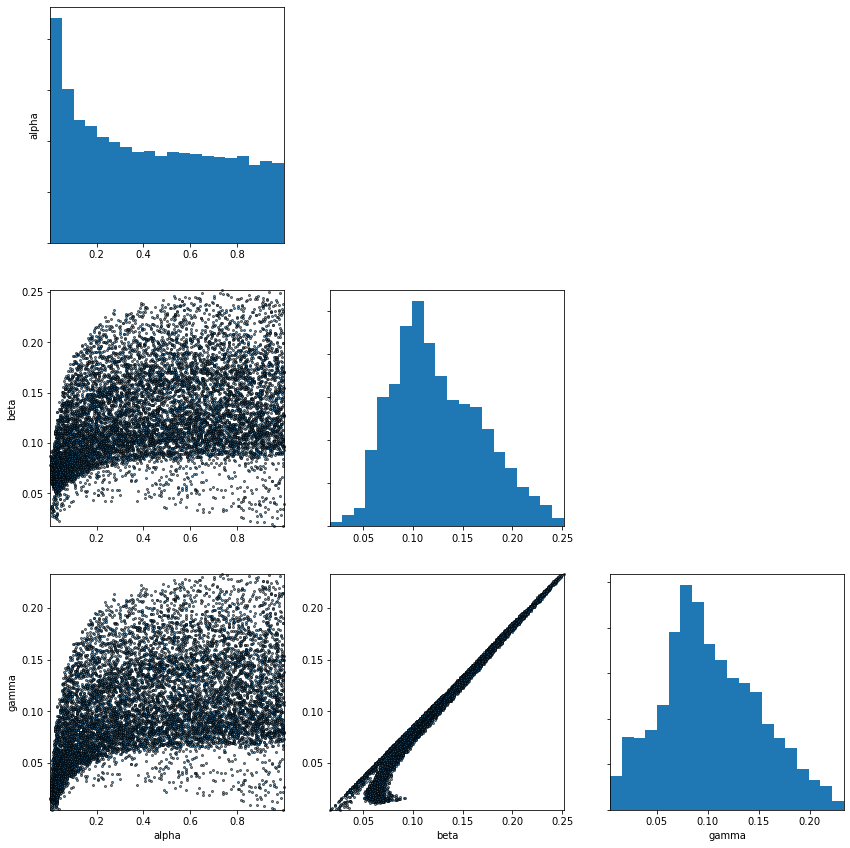

In [18]:
result.plot_pairs()
plt.savefig(os.path.join(output_directory, "plot_pairs.pdf"))

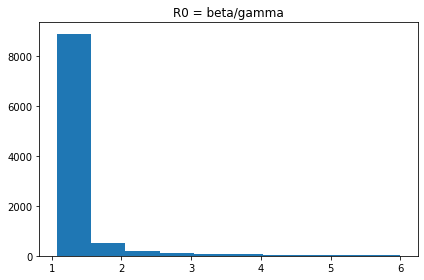

Mean of R: 1.3589442222923949
Median of R: 1.2061385689003128


In [19]:
# Plotting R0

if not reparam:
    if pars[1] == "tau":
        print("Using tau = 1/gamma")
        R0 = result.samples[pars[0]]*result.samples[pars[1]]
    else:
        R0 = result.samples[pars[0]]/result.samples[pars[1]]
else:
    R0 = result.samples['R']

plt.hist(R0)
plt.title("R0 = beta/gamma")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"R0_hist.pdf"), format="pdf", bbox_inches="tight")
plt.show()

print(f"Mean of R: {R0.mean()}")
print(f"Median of R: {np.median(R0)}")

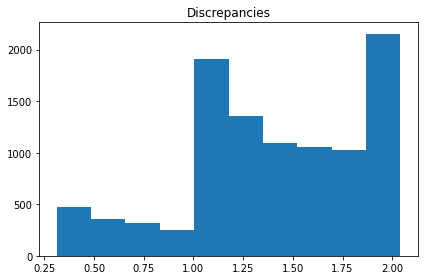

In [20]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"discrepancy_hist.pdf"), format="pdf", bbox_inches="tight")
plt.show()

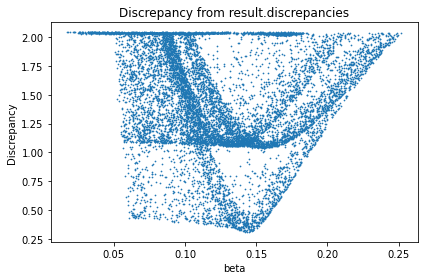

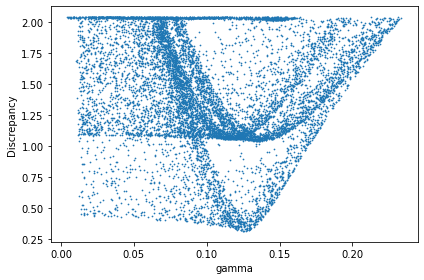

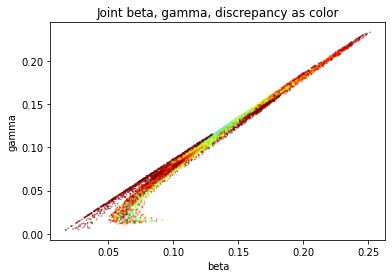

In [21]:
plt.scatter(result.samples[par1], result.discrepancies, s = 0.5)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"{par1}_discrepancy_scatter.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies, s = 0.5)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"{par2}_discrepancy_scatter.pdf"), format="pdf", bbox_inches="tight")
plt.show()


plt.scatter(result.samples[par1], result.samples[par2], c = result.discrepancies, alpha = 0.5, s = 0.5)
plt.title("Joint beta, gamma, discrepancy as color")
plt.xlabel(par1)
plt.ylabel(par2)
plt.set_cmap('jet')
plt.show()

In [24]:
def ppc(par1, par2, variables, n_sample = 1000):
    
    indx = np.random.choice(np.arange(0, len(result.samples[par1])), n_sample) # Ensure that the samples are joint samples by using a same set of indices for all parameters of interest.

    par1_post = result.samples[par1][indx]
    par2_post = result.samples[par2][indx]
    
    if not "l" in variables:
        #l_post = l.generate(1)
        theta_bsi_post = theta_bsi.generate(1)#, with_values = {"l":l_post})
    else:
        l_post = result.samples["l"][indx]
        theta_bsi_post = theta_bsi.generate(1, with_values = {"l":l_post})
    
    if not "alpha" in variables:
        alpha_post = alpha.generate(1)
    else:
        alpha_post = result.samples["alpha"][indx]
        
    n_rep = 1
    
    if not is_SIS:
        SIR_pred = SIRsim.generate(n_rep , with_values = {par1:par1_post, par2:par2_post})
        BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":OR_hat.generate(1), "theta_bsi": theta_bsi_post})

    else:
        SIS_pred = SISsim.generate(n_rep , with_values = {par1:par1_post, par2:par2_post})
        BSI_pred = BSI.generate(n_rep, with_values = {"SISsim":SIS_pred, "OR_hat":OR_hat.generate(1), "theta_bsi": theta_bsi_post})
        
    
    BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})
    BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred, "alpha":alpha_post}) # , "alpha": alpha_post
    
    plt.hist(par1_post, alpha = 0.5, label = f"{par1}")
    plt.hist(par2_post, alpha = 0.5, label = f"{par2}")
    plt.legend()
    plt.title(f"Posterior sample, n_sample = {n_sample}")
    plt.show()

    if is_SIS:
        return SIS_pred, BSI_pred, BSI_yearly_pred, BSI_conv_pred
    else:
        return SIR_pred, BSI_pred, BSI_yearly_pred, BSI_conv_pred



def visualize_ppc(BSI_conv_pred, bsi_obs_data, clade = clade, ci = 95):
    # Visualize posterior predictive check
    expected_value = np.mean(BSI_conv_pred, axis = 0)
    med = np.median(BSI_conv_pred, axis = 0)
    cis = np.percentile(BSI_conv_pred, [(100-ci)/2, 100 - (100-ci)/2], axis = 0)

    plt.plot(expected_value, label = "mean", color = "blue")
    plt.plot(med, label = "median", color = "lightblue")
    plt.plot(cis[0,:], label = f"Lower {ci}% CI", color = "gray")
    plt.plot(cis[1,:], label = f"Upper {ci}% CI", color = "gray")
    plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "orange")
    plt.legend()
    plt.title(f"Clade {clade} Pointwise Posterior Predictive")
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"pred_obs_BSI.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

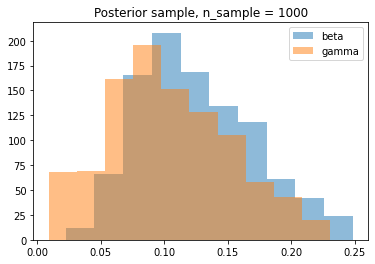

In [25]:
if is_SIS:
    SIS_pred, BSI_pred, BSI_yearly_pred, BSI_conv_pred = ppc(par1 = "beta", par2 = "gamma", variables = variables)
else:
    SIR_pred, BSI_pred, BSI_yearly_pred, BSI_conv_pred = ppc(par1 = "beta", par2 = "gamma", variables = variables)

In [26]:
# Save the output of nodes

import csv

if is_SIS:
    SIR_pred = SIS_pred

def write_node_to_file(node_data, fname):
    # Write node_data (shaped (n_sample, n_timepoints) to a csv file
    
    with open(os.path.join(output_directory, fname), "w") as csvfile:
    
        nt = node_data.shape[1]
        
        datawriter = csv.writer(csvfile)
        datawriter.writerow(np.arange(1, nt+1))

        for i in range(0, node_data.shape[0]):
            datawriter.writerow(node_data[i])


# S
write_node_to_file(SIR_pred[0], "SIR-S_node.csv")
    
# I
write_node_to_file(SIR_pred[1], "SIR-I_node.csv")

# R
if not is_SIS:
    write_node_to_file(SIR_pred[2], "SIR-R_node.csv")

# Weekly BSI
write_node_to_file(BSI_pred, "BSI_weekly_node.csv")

# Yearly BSI
write_node_to_file(BSI_yearly_pred, "BSI_yearly_node.csv")

# Conv BSI
write_node_to_file(BSI_conv_pred, "BSI_conv_node.csv")



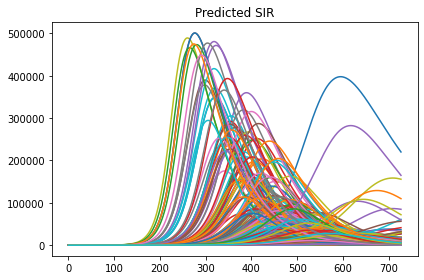

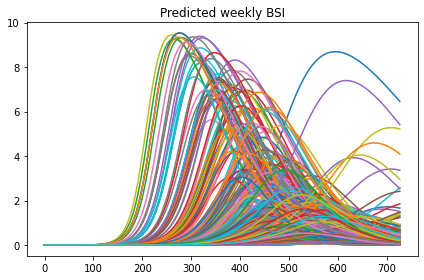

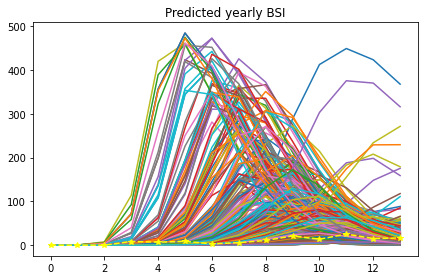

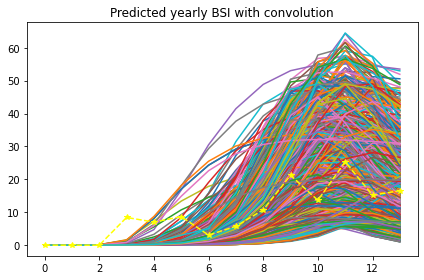

In [27]:
plt.plot(SIR_pred[1].T)
plt.title("Predicted SIR")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_SIR.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.plot(BSI_pred.T)
plt.title("Predicted weekly BSI")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.plot(BSI_yearly_pred.T)
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "yellow")
plt.title("Predicted yearly BSI")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.plot(BSI_conv_pred.T)
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "yellow")
plt.title("Predicted yearly BSI with convolution")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_yearly_conv_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

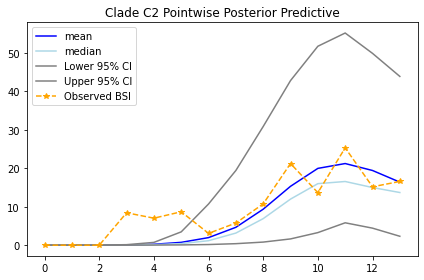

In [28]:
visualize_ppc(BSI_conv_pred, bsi_obs_data)

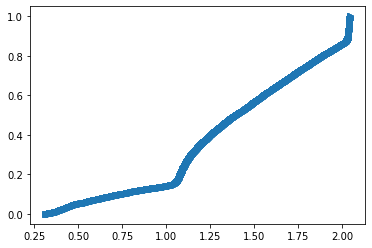

In [29]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

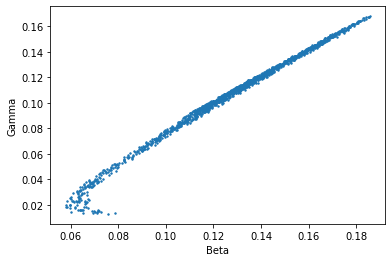

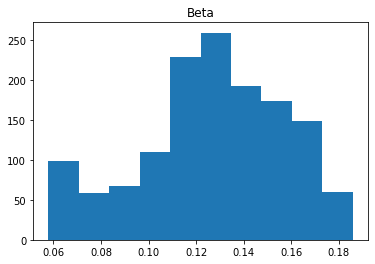

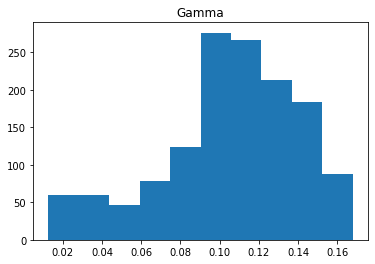

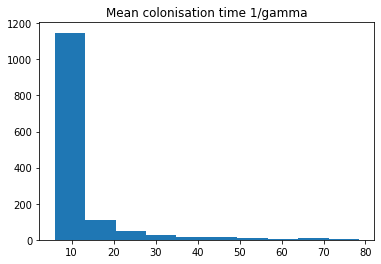

In [45]:
eps = 1
p1 = result.samples[par1][np.where(result.discrepancies < eps)]
p2 = result.samples[par2][np.where(result.discrepancies < eps)]

plt.scatter(p1, p2, s = 2)
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.show()

plt.hist(p1)
plt.title("Beta")
plt.show()

plt.hist(p2)
plt.title("Gamma")
plt.show()

plt.hist(1/p2)
plt.title("Mean colonisation time 1/gamma")
plt.show()

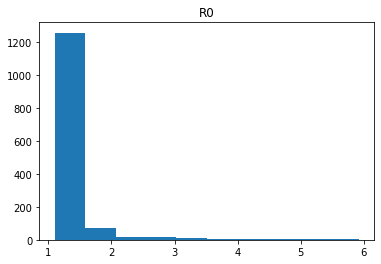

R0 mean: 1.3306024352840553
R0 median: 1.1805631390668876


In [46]:
if not reparam:
    plt.hist(p1/p2)
    plt.title("R0")

    plt.show()
    print(f"R0 mean: {np.mean(p1/p2)}")
    print(f"R0 median: {np.median(p1/p2)}")
else:
    plt.hist(p2)
    plt.show()
    print(f"R mean: {np.mean(p2)}")
    print(f"R median: {np.median(p2)}")
    
    

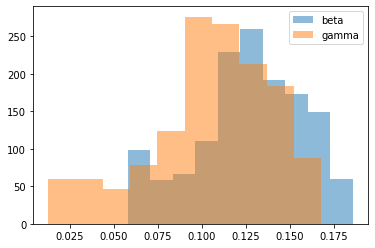

(14,)
(2, 14)


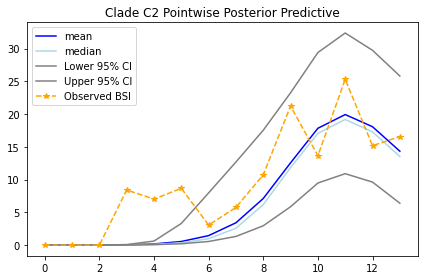

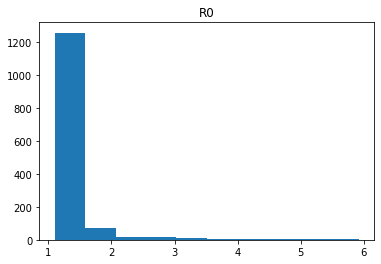

R0 mean: 1.3306024352840553
R0 median: 1.1805631390668876


In [47]:
# Posterior predictive with updated threshold value:
par1_acc_sample = result.samples[variables[0]][np.where(result.discrepancies < eps)]
par2_acc_sample = result.samples[variables[1]][np.where(result.discrepancies < eps)]

#par1_acc_sample = par1_acc_sample[np.where(par2_acc_sample <= 0.04)]
#par2_acc_sample = par2_acc_sample[np.where(par2_acc_sample <= 0.04)]


#indx = np.random.choice(np.arange(0, len(par1_acc_sample)), n_sample) # Ensure that the samples are joint samples by using a same set of indices for all parameters of interest.

par1_post = par1_acc_sample
par2_post = par2_acc_sample




if not "l" in variables:
    pass
    l_post = 1 #l.generate(1)
else:
    l_acc_sample = result.samples["l"][np.where(result.discrepancies < eps)]
    l_post = l_acc_sample.copy()
if not "alpha" in variables:
    alpha_post = alpha.generate(1)
else:
    a_acc_sample = result.samples["alpha"][np.where(result.discrepancies < eps)]
    alpha_post = a_acc_sample

n_rep = 1 # Should this actually be just one?

theta_bsi_post = theta_bsi.generate(n_rep, with_values = {"l":l_post})

# Start generating from nodes based on these posterior samples:

if not is_SIS:
    SIR_pred = SIRsim.generate(n_rep , with_values = {par1:par1_post, par2:par2_post})
    BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":OR_hat.generate(1), "theta_bsi": theta_bsi_post})

else:
    SIS_pred = SISsim.generate(n_rep , with_values = {par1:par1_post, par2:par2_post})
    BSI_pred = BSI.generate(n_rep, with_values = {"SISsim":SIS_pred, "OR_hat":OR_hat.generate(1), "theta_bsi": theta_bsi_post})

#print(SIR_pred[0].shape) # (n_sample, T), where T = n_year*52 = 728 (one curve for each posterior sample point)


  

BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})
BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred, "alpha":alpha_post}) # , "alpha": alpha_post

# Save posteriors with a threshold

# S
write_node_to_file(SIR_pred[0], "SIR-S_node.csv")
    
# I
write_node_to_file(SIR_pred[1], "SIR-I_node.csv")

# R
if not is_SIS:
    write_node_to_file(SIR_pred[2], "SIR-R_node.csv")

# Weekly BSI
write_node_to_file(BSI_pred, "BSI_weekly_node.csv")

# Yearly BSI
write_node_to_file(BSI_yearly_pred, "BSI_yearly_node.csv")

# Conv BSI
write_node_to_file(BSI_conv_pred, "BSI_conv_node.csv")



plt.hist(par1_post, alpha = 0.5, label = f"{par1}")
plt.hist(par2_post, alpha = 0.5, label = f"{par2}")
plt.legend()
#plt.title(f"Posterior sample, n_sample = {n_sample}")
plt.show()

expected_value = np.mean(BSI_conv_pred, axis = 0)
med = np.median(BSI_conv_pred, axis = 0)
ci = 95
cis = np.percentile(BSI_conv_pred, [(100-ci)/2, 100 - (100-ci)/2], axis = 0)
print(expected_value.shape)
print(cis.shape)
plt.plot(expected_value, label = "mean", color = "blue")
plt.plot(med, label = "median", color = "lightblue")
plt.plot(cis[0,:], label = f"Lower {ci}% CI", color = "gray")
plt.plot(cis[1,:], label = f"Upper {ci}% CI", color = "gray")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--', color = "orange")
plt.legend()
plt.title("Clade C2 Pointwise Posterior Predictive")
plt.tight_layout()
plt.savefig(os.path.join(output_directory, f"pred_obs_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()

plt.hist(par1_acc_sample/par2_acc_sample)
plt.title("R0")
plt.show()
print(f"R0 mean: {np.mean(par1_acc_sample/par2_acc_sample)}")
print(f"R0 median: {np.median(par1_acc_sample/par2_acc_sample)}")


In [48]:
# Save the posterior samples again with a threshold value eps
import csv

with open(os.path.join(output_directory, "result_samples.csv"), "w") as csvfile:
    
    datawriter = csv.writer(csvfile)
    datawriter.writerow(["beta", "gamma", "alpha"])
    
    #res = result.samples[np.where(result.discrepancies < eps)
    
    for i in range(0, len(result.samples["beta"][np.where(result.discrepancies < eps)])):
        
        row = [result.samples["beta"][np.where(result.discrepancies < eps)][i],\
               result.samples["gamma"][np.where(result.discrepancies < eps)][i],\
               result.samples["alpha"][np.where(result.discrepancies < eps)][i]]
        #print(row)
        
        datawriter.writerow(row)